# The College town factor: The effect of colleges on housing prices in U.S. cities with populations less than 250,000

**College Town definition**: Throughout this study, a **college town** is defined as a U.S. city home to at least one college or university and with a population of fewer than 250,000 people.

In [1]:
## load libraries
import pandas as pd
import numpy as np

## For Visualizing
import matplotlib.pyplot as plt
import seaborn as sns

---

## Introduction

Initial data exploration indicates that in the years since 1996, college towns have seen a higher average increase in both single-family home sale prices, as well as in population, than have like-sized, non-college town cities. Is the presence of a college or university a factor in this? Is it that college towns have a slightly higher population size? Or is this difference just an illusion created by the effects of compound inflation?

This study aims to broadly examine the question of whether college towns are better financial investments than non-college towns by answering specific research questions. These questions evaluate the return on investment in good years and the reduction of risk in down years, including during extreme events such as the 2008 housing bubble and subsequent crash, the long recovery from the great recession, and the early months of the 2020 COVID pandemic.

In [2]:
# Import dataset
data = pd.read_csv("working_dataset.csv")

### Comparing the distribution of population sizes in college and non-college towns

Of cities with populations less than 250,000, those with colleges are, on average, larger (55,419.14 population mean compared to 6,019.91). The Standard Deviation is also higher (59,629.38 std compared to 14,782.51).

In [55]:
data_ct = data.loc[(data.colleges_count > 0)]
data_nct = data.loc[(data.colleges_count == 0)]

print( "Non-college town population mean (cities < 250,000): {:.2f}".format( data_nct.pop_2010.mean()) ) 
print( "College town population mean (cities < 250,000): {:.2f}".format( data_ct.pop_2010.mean()) ) 

print( "Non-college town population standard deviation (cities < 250,000): {:.2f}".format( data_nct.pop_2010.std()) ) 
print( "College town population standard deviation (cities < 250,000): {:.2f}".format( data_ct.pop_2010.std()) ) 

Non-college town population mean (cities < 250,000): 6019.91
College town population mean (cities < 250,000): 55419.14
Non-college town population standard deviation (cities < 250,000): 14782.51
College town population standard deviation (cities < 250,000): 59629.38


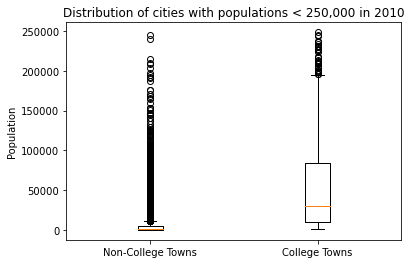

In [56]:
fig1, ax1 = plt.subplots()
plt.ylabel('Population')
ax1.set_title('Distribution of cities with populations < 250,000 in 2010')
dataA = data.loc[(data.colleges_count == 0)]['pop_2010']
dataB = data.loc[(data.colleges_count > 0)]['pop_2010']
ax1.boxplot( [ dataA, dataB ], showfliers=True, labels=[ "Non-College Towns", "College Towns"])
plt.show()

### Population Growth of college towns and non-college towns between 2010 and 2019 

In [66]:
index = data.loc[:,'pop_2010':'pop_2019'].columns.tolist()
columns = ['nct_pop', 'ct_pop']
array = np.zeros( ( len(index), len(columns) ), dtype=float )
compare_mean_pop = pd.DataFrame(array, columns=columns, index=index)

In [67]:
for column in data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    compare_mean_pop['nct_pop'][column] = data[column].loc[ (data[column] > 0) & (data['colleges_count'] == 0) ].mean()

for column in data.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    compare_mean_pop['ct_pop'][column] = data[column].loc[ (data[column] > 0) & (data['colleges_count'] > 0) ].mean()

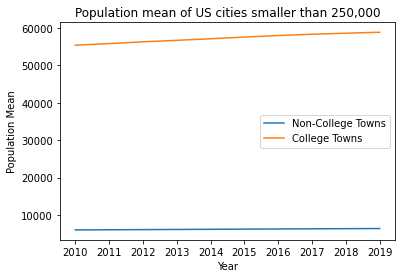

In [69]:
v1 = compare_mean_pop.nct_pop
v2 = compare_mean_pop.ct_pop
years = compare_mean_pop.index.tolist()

fig = plt.figure()
plt.plot(years, v1, label="Non-College Towns")
plt.plot(years, v2, label="College Towns")
plt.title('Population mean of US cities smaller than 250,000')
plt.xlabel('Year')
plt.xticks(["pop_2010", "pop_2011", "pop_2012", "pop_2013", "pop_2014", "pop_2015", "pop_2016", "pop_2017", "pop_2018", "pop_2019"],
          ["2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019"])
plt.ylabel('Population Mean')
plt.legend()

plt.show()

In [68]:
nct_mean_2010 = compare_mean_pop['nct_pop']['pop_2010']
nct_mean_2019 = compare_mean_pop['nct_pop']['pop_2019']
ct_mean_2010 = compare_mean_pop['ct_pop']['pop_2010']
ct_mean_2019 = compare_mean_pop['ct_pop']['pop_2019']


print("In 2010, the mean population size of college towns was {:.2f} compared to {:.2f} for non-college towns. By 2019, the population means had increased to {:.2f} and {:.2f}, respectively. This increase represents a population growth of {:.2f} for college towns compared to only {:.2f} for non-college towns over that period.".format( ct_mean_2010, nct_mean_2010, ct_mean_2019, nct_mean_2019, (ct_mean_2019 - ct_mean_2010), (nct_mean_2019 - nct_mean_2010) ))

In 2010, the mean population size of college towns was 55419.14 compared to 6019.91 for non-college towns. By 2019, the population means had increased to 58891.98 and 6389.70, respectively. This increase represents a population growth of 3472.84 for college towns compared to only 369.79 for non-college towns over that period.


### Average Sale Price of single homes between 1996 and 2021 fro College and Non-college towns

In [85]:
index = data.loc[:,'1996-01-31':'2020-09-30'].columns.tolist()
columns = ['nct_price', 'ct_price']
array = np.zeros( ( len(index), len(columns) ), dtype=float )
compare_price = pd.DataFrame(array, columns=columns, index=index)

In [86]:
for column in data.loc[:,'1996-01-31':'2020-09-30'].columns.tolist():
    compare_price['nct_price'][column] = data[column].loc[ (data[column] > 0) & (data['colleges_count'] == 0) ].mean()

for column in data.loc[:,'1996-01-31':'2020-09-30'].columns.tolist():
    compare_price['ct_price'][column] = data[column].loc[ (data[column] > 0) & (data['colleges_count'] > 0) ].mean()

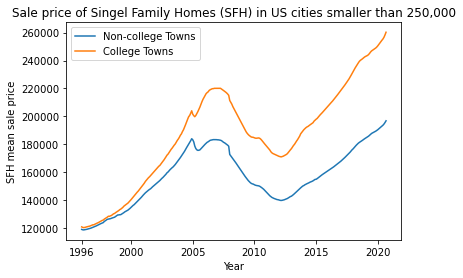

In [87]:
v1 = compare_price.nct_price
v2 = compare_price.ct_price
years = compare_price.index.tolist()

plt.title('Sale price of Singel Family Homes (SFH) in US cities smaller than 250,000')
plt.ylabel('SFH mean sale price')
plt.xlabel('Year')
plt.plot(years, v1, label="Non-college Towns")
plt.plot(years, v2, label="College Towns")
plt.xticks(['1996-01-31','2000-01-31','2005-01-31','2010-01-31','2015-01-31','2020-01-31'],
           ['1996', '2000', '2005', '2010', '2015', '2020'])
plt.legend()

plt.show()

In [90]:
nct_price_1996 = compare_mean_price['nct_price']['1996-01-31']
nct_price_2020 = compare_mean_price['nct_price']['2020-09-30']
ct_price_1996 = compare_mean_price['ct_price']['1996-01-31']
ct_price_2020 = compare_mean_price['ct_price']['2020-09-30']


print("In 2010, the average sale price of a single-family home in a college-town was ${:.2f}, compared with ${:.2f} in non-college towns. By 2019, the average sale prices had increased to ${:.2f} and ${:.2f}, respectively. College towns saw an increase of ${:.2f}, whereas non-college towns only saw an increase of ${:.2f} over this twenty-three year period.".format( ct_price_1996, nct_price_1996, ct_price_2020, nct_price_2020, (ct_price_2020 - ct_price_1996), (nct_price_2020 - nct_price_1996) ))

In 2010, the average sale price of a single-family home in a college-town was $121092.82, compared with $119271.82 in non-college towns. By 2019, the average sale prices had increased to $260205.90 and $196894.98, respectively. College towns saw an increase of $139113.08, whereas non-college towns only saw an increase of $77623.16 over this twenty-three year period.


---

## Data description

ANSWER THIS:

What are the observations (rows) and the attributes (columns)?
Why was this dataset created?
Who funded the creation of the dataset?
What processes might have influenced what data was observed and recorded and what was not?
What preprocessing was done, and how did the data come to be in the form that you are using?
If people are involved, were they aware of the data collection and if so, what purpose did they expect the data to be used for?
Where can your raw source data be found, if applicable? Provide a link to the raw data (hosted in a Cornell Google Drive or Cornell Box). 


### Dataset sources
The dataset used in this study is the product of combining three data sources:

#### 1. Zillow house sale prices
Zillow provides time-series data on house sale prices for towns and cities in the United States (https://www.zillow.com/research/data/). This is using their "ZHVI Single Family Homes Time Series($)" Dataset for US Cities. Zillow makes this data publicly available in the hopes that users will create better home-value predictive models. This dataset averages sale prices of single-family homes at a city level so no personal information is being made public. Zillow does make datasets available at both coarser and finer levels of detail ranging from State to neighborhood.

#### 2. US Census Population data
The US Census provides time-series data for populations of Incorporated Places in the United States from 2010 to 2019 (https://www.census.gov/data/tables/time-series/demo/popest/2010s-total-cities-and-towns.html). The Census collects and publishes this data as is required by the US constitution.

#### 3. College towns in the United States
Data scraped from https://en.wikipedia.org/wiki/List_of_college_towns filtered to include only cities in the United States. This data is publicly created and edit and distributed under the Creative Commons Attribution-ShareAlike License.

### Dataset description
The resulting dataset used in this study contains 310 columns and 16,885 rows. The columns contain information on the following variables:

- __city__: The city's name
- __city_state__: the state abreviation of the state the city is in
- __colleges_count__: the number of colleges/universities in the city
- __pop_2010__ through __pop_2019__: the population of the city each year between 2010 and 2019 inclusive
- __1996-01-31__ through __2020-09-30__: the average sale price of single familily homes in that city for each month between January, 1996 and September 2020.

Each row represents a U.S. city with a population of less than 250,000 in 2010. Each observation contains city, state, college count, and population data. The level of completeness for home sale price data varies, however, especial in the earlier years in the date range.

### Data processing
Some data was lost in the merging of datasets due to mismatches in observation identifiers (city names and states). 

For complete information on data sources, cleanup, and sample size selection, see __Appendix - Datasets: Sources and cleanup__.

### Raw Data
Individual datasets can be found via the following links:

The final, merged dataset used in this study can be downloaded here:


---

## Preregistration statement


In years when the average sale price of single family homes rises, do college towns see a higher increase in home sale prices from the previous year than do non-college towns.

In years when the average sale price of single family homes falls, do college towns see a lower decreases in home sale prices from the previous year than do non-college towns.

Is the presence of a college town a stronger predictor of higher increase in home values than is population size.

Are the above values consitnent in the months since March 2020 with the historic values since 1996.

## Evaluation of significance


## Interpretation and conclusions


## Limitations


## Source code


## Acknowledgments


## Appendix - Datasets: Sources and cleanup